In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

In [23]:
# Read data from the sorce file
df = pd.read_csv("../data/raw/AmesHousing.csv")

# Show imported data
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [24]:
# Check shape of the dataframe
df.shape
# Medium size dataset

(2930, 82)

In [25]:
# Show datatypes and lack of data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [26]:
# Statistics description for variables
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [ ]:
"""
## Summary Statistics

Basic descriptive statistics were calculated for numerical variables in the dataset.

For the target variable (*SalePrice*), the results indicate that the mean price is higher than the median, confirming the right-skewed distribution observed earlier. This suggests that a relatively small number of high-value properties increases the average price.

The wide range between minimum and maximum values reflects significant variability in property prices. Additionally, the standard deviation indicates a high dispersion of values, which is typical for real estate markets.

Overall, the summary statistics confirm that the dataset contains a diverse set of properties with varying characteristics and price levels.

"""

In [27]:
""" 
Medium size database 
Target data -> SalePrice

Goal:
Whats the impact of diffrent variables on Sale Price
"""

' \nMedium size database \nTarget data -> SalePrice\n\nGoal:\nWhats the impact of diffrent variables on Sale Price\n'

In [28]:
num_cols = df.select_dtypes(include=["int64", "float64"])
cat_cols = df.select_dtypes(include=["str"])

print("num_cols = ",len(num_cols.columns), "\ncat_cols = ",len(cat_cols.columns))

num_cols =  39 
cat_cols =  43


In [29]:
num_cols.info()
if "Order" not in num_cols:
    print("Id not in num_col")
if "SalePrice" not in num_cols:
    print("Id not in num_col")

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Overall Qual     2930 non-null   int64  
 6   Overall Cond     2930 non-null   int64  
 7   Year Built       2930 non-null   int64  
 8   Year Remod/Add   2930 non-null   int64  
 9   Mas Vnr Area     2907 non-null   float64
 10  BsmtFin SF 1     2929 non-null   float64
 11  BsmtFin SF 2     2929 non-null   float64
 12  Bsmt Unf SF      2929 non-null   float64
 13  Total Bsmt SF    2929 non-null   float64
 14  1st Flr SF       2930 non-null   int64  
 15  2nd Flr SF       2930 non-null   int64  
 16  Low Qual Fin SF  2930 non-null   int64  
 17  Gr Liv Area      2930 non

In [30]:
"""
Order is an id of every transaction -> not importen, no impact on SalePrice
"""
df["Order"].head(81)

0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
9     10
10    11
11    12
12    13
13    14
14    15
15    16
16    17
17    18
18    19
19    20
20    21
21    22
22    23
23    24
24    25
25    26
26    27
27    28
28    29
29    30
30    31
31    32
32    33
33    34
34    35
35    36
36    37
37    38
38    39
39    40
40    41
41    42
42    43
43    44
44    45
45    46
46    47
47    48
48    49
49    50
50    51
51    52
52    53
53    54
54    55
55    56
56    57
57    58
58    59
59    60
60    61
61    62
62    63
63    64
64    65
65    66
66    67
67    68
68    69
69    70
70    71
71    72
72    73
73    74
74    75
75    76
76    77
77    78
78    79
79    80
80    81
Name: Order, dtype: int64

In [31]:

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_percent
})

missing_df[missing_df["missing_percent"]>40].sort_values(by="missing_percent", ascending=False) 

,missing_count,missing_percent
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423


In [32]:
"""
High percentage of missing values in variables such as Pool QC, Alley, and Fence 
likely indicates absence of these features rather than missing data
"""

'\nHigh percentage of missing values in variables such as Pool QC, Alley, and Fence \nlikely indicates absence of these features rather than missing data\n'

In [33]:
print(  df["Pool QC"].value_counts(dropna=False),
        df["Misc Feature"].value_counts(dropna=False),
        df["Alley"].value_counts(dropna=False),
        df["Fence"].value_counts(dropna=False),
        df["Mas Vnr Type"].value_counts(dropna=False),
        df["Fireplace Qu"].value_counts(dropna=False),sep = "\n\n")



Pool QC
NaN    2917
Ex        4
Gd        4
TA        3
Fa        2
Name: count, dtype: int64

Misc Feature
NaN     2824
Shed      95
Gar2       5
Othr       4
Elev       1
TenC       1
Name: count, dtype: int64

Alley
NaN     2732
Grvl     120
Pave      78
Name: count, dtype: int64

Fence
NaN      2358
MnPrv     330
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64

Mas Vnr Type
NaN        1775
BrkFace     880
Stone       249
BrkCmn       25
CBlock        1
Name: count, dtype: int64

Fireplace Qu
NaN    1422
Gd      744
TA      600
Fa       75
Po       46
Ex       43
Name: count, dtype: int64


In [34]:
"""High proportion of missing values in variables such as Pool QC, Alley, and Fence 
does not indicate data quality issues. Instead, it reflects the absence of these features in most properties."""

'High proportion of missing values in variables such as Pool QC, Alley, and Fence \ndoes not indicate data quality issues. Instead, it reflects the absence of these features in most properties.'

In [ ]:
"""
## Specific Characteristics of the Dataset

Several non-standard properties were identified during the analysis of the dataset.

Firstly, missing values do not necessarily indicate data quality issues. In many cases, they represent the absence of a feature rather than missing information. For example, variables such as *Pool QC*, *Alley*, *Fence*, and *Fireplace Qu* contain a high number of missing values, which correspond to properties lacking these features.

Secondly, the dataset is highly imbalanced in terms of feature occurrence. Some attributes, such as pools, appear very rarely, while others are much more common. This imbalance should be considered when interpreting the results.

Finally, the target variable (*SalePrice*) exhibits a right-skewed distribution with a long tail of high-value properties. The distribution also suggests the presence of different price segments within the housing market.

"""

In [36]:
df[["Mas Vnr Type", "Mas Vnr Area"]].head(81)


,Mas Vnr Type,Mas Vnr Area
0,Stone,112.0
1,NaN,0.0
2,BrkFace,108.0
3,NaN,0.0
4,NaN,0.0
5,BrkFace,20.0
6,NaN,0.0
7,NaN,0.0
8,NaN,0.0
9,NaN,0.0


<Axes: xlabel='SalePrice', ylabel='Count'>

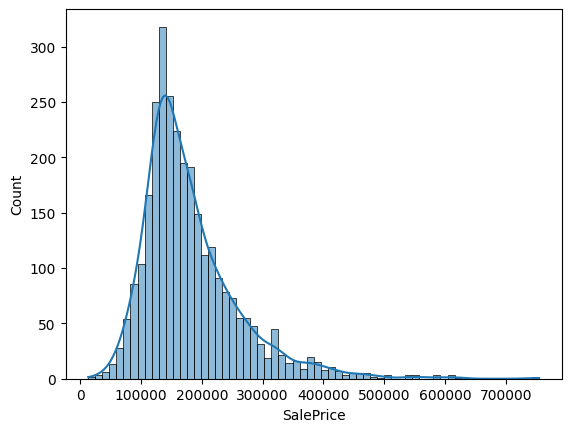

In [41]:

sns.histplot(df["SalePrice"], kde=True)

<Axes: xlabel='Has_Fireplace', ylabel='SalePrice'>

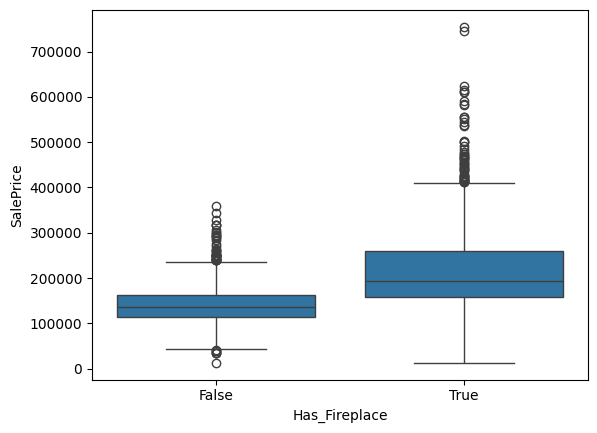

In [ ]:
# Check boxplot for houses with fireplace
df["Has_Fireplace"] = df["Fireplace Qu"].notnull()
sns.boxplot(x="Has_Fireplace", y="SalePrice", data=df)

In [ ]:
"""
Properties with a fireplace have significantly higher median sale prices compared to those without. The entire distribution is shifted upward, indicating that the presence of a fireplace is associated with higher property value.
"""

<Axes: xlabel='Has_Pool', ylabel='SalePrice'>

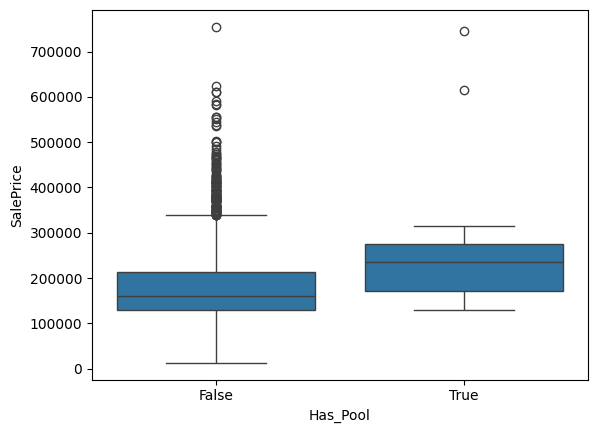

In [ ]:
# Check boxplot for houses with pool
df["Has_Pool"] = df["Pool QC"].notnull()
sns.boxplot(x="Has_Pool", y="SalePrice", data=df)

In [ ]:
"""
Properties with a pool tend to have higher sale prices, as indicated by a higher median. However, the number of such observations is very small, which limits the reliability of this conclusion.
"""

<Axes: xlabel='Has_Fence', ylabel='SalePrice'>

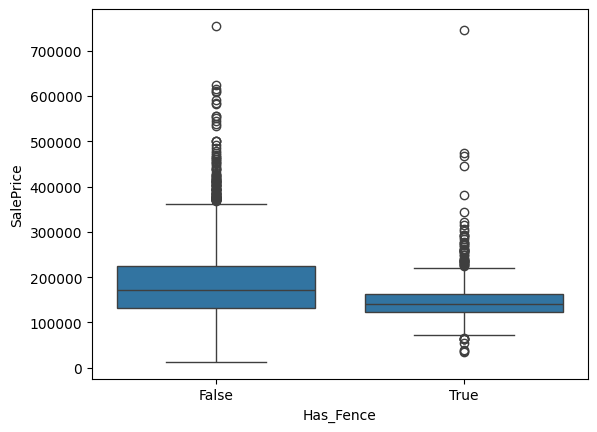

In [ ]:
# Check boxplot for houses with fence
df["Has_Fence"] = df["Fence"].notnull()
sns.boxplot(x="Has_Fence", y="SalePrice", data=df)

In [52]:
"""
Properties without a fence appear to have slightly higher median prices. However, this relationship is not straightforward and may be influenced by other factors such as location or neighborhood characteristics.
"""

'\nProperties without a fence appear to have slightly higher median prices. However, this relationship is not straightforward and may be influenced by other factors such as location or neighborhood characteristics.\n'

In [53]:
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Has_Fireplace      0.481446
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Has_Pool           0.087960
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0

In [ ]:
"""
## Correlation Analysis

To identify the most important factors influencing property prices, a correlation analysis was performed for numerical variables.

The results indicate that the strongest relationships with *SalePrice* are observed for the following variables:

* *Overall Qual* (correlation ≈ 0.80)
* *Gr Liv Area* (correlation ≈ 0.71)
* *Garage Cars* (correlation ≈ 0.65)
* *Garage Area* (correlation ≈ 0.64)
* *Total Bsmt SF* (correlation ≈ 0.63)

These results suggest that both the overall quality of the building and its size play a crucial role in determining property value. In particular, *Overall Qual* shows the highest correlation, indicating that better construction and finishing standards are strongly associated with higher prices.

Additionally, variables related to usable space, such as above-ground living area (*Gr Liv Area*) and basement size (*Total Bsmt SF*), are also strongly correlated with price. Garage-related features further contribute to property value, suggesting that functionality and convenience are important factors for buyers.

It should be noted that correlation does not imply causation; however, these variables clearly show strong associations with housing prices and are key predictors in the dataset.

"""

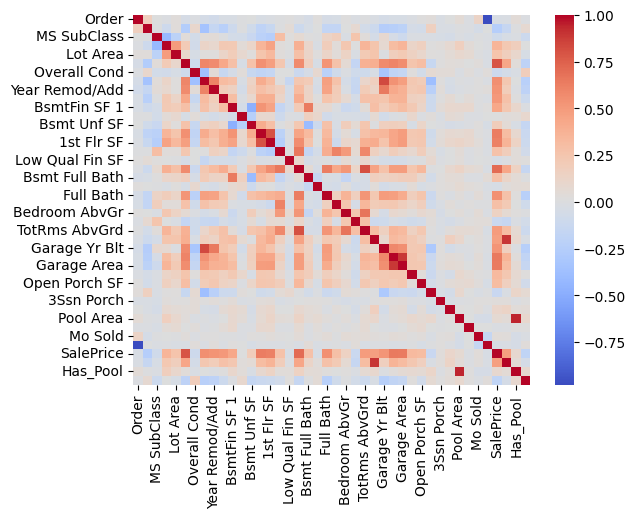

In [54]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.savefig("correlation.png")